In [ ]:
'''
ML Pipeline for Gridded Precip Project (XGBoost) - both IDW and kriging input options

Overview and Motivation
The goal of this workflow is to integrate heterogeneous observational, satellite, and climatological datasets into a unified, physically informed ML framework
for predicting precipitation phase (rain, snow, or mixed). Because direct precipitation-phase observations are sparse and unevenly distributed in space and time,
we adopt a weakly supervised labeling approach using an interpolated MRoS proxy, combined with spatially blocked ML training to handle prediction across complex terrain.

1. Gridded surface preprocessing
All predictor layers are aligned to a common coordinate reference system, grid resolution, and timestamp index.
Output: Stacked gridded predictor datasets (NetCDF), one layer per variable per hour.

2. Precip phase labeling via MRoS proxy
The interpolated MRoS proxy surface is converted into discrete phase classes
The MRoS proxy is used exclusively for labeling and is not included as a predictor to avoid target leakage.
Output: A space-time mask identifying gridcell-hours with usable phase labels.

3. Feature table construction:
Transform gridded data back into tabular format required for ML processing.
Output: a tabular dataset (e.g., parquet) suitable for ML training

4. Spatial blocking to split data
Motivation: spatial blocking accounts for spatial autocorrelation and avoids overestimated performance that arise from random splits.

5. ML model training
XGBoost binary classifier:
Target: predict rain or snow probabilities, and hiearchical structure determines if they're not decisive, label as mix.
Outputs class probabilities (& uncertainty)
Model hyperparameter tuning on validation set (tree depth, learning rate, subsampling, min_child_weight, etc.)
Stopping criteria via early stopping on validation loss

6. Model evaluation and performance
Model performance is evaluated on a fully held-out test set.
'''

'\nML Pipeline for Gridded Precip Project (XGBoost)\n\nOverview and Motivation\nThe goal of this workflow is to integrate heterogeneous observational, satellite, and climatological datasets into a unified, physically informed ML framework \nfor predicting precipitation phase (rain, snow, or mixed). Because direct precipitation-phase observations are sparse and unevenly distributed in space and time, \nwe adopt a weakly supervised labeling approach using an interpolated MRoS proxy, combined with spatially blocked ML training to handle prediction across complex terrain.\n\n1. Gridded surface preprocessing\nAll predictor layers are aligned to a common coordinate reference system, grid resolution, and timestamp index.\nOutput: Stacked gridded predictor datasets (NetCDF), one layer per variable per hour.\n\n2. Precip phase labeling via MRoS proxy\nThe interpolated MRoS proxy surface is converted into discrete phase classes:\nThe MRoS proxy is used exclusively for labeling and is not include

Key updates:
- removing overlapping air temp and dew temp variables from different data sources. Instead, introducing anomaly air temp and dew temp from PRISM compared to station data.
- thresholding update: implementing <=20 snow and >= rain... with remainder as mix. Introducing label confidence values.
- removing prism_ppt_daily
- including label confidence weights on top of existing class rebalancing. Also, transition-window upweight (focus on 0–4°C wet-bulb)
- replacing softmax multiclass training with binary training + abstention logic (binary snow vs rain probability model --> if probabilities aren’t decisive, label as mix/uncertain). This directly operationalizes the “transition zone overlap” idea: it’s not that “mix is a third clean class,” it’s often an inseparable region using surface meteorology

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [3]:
BASE_DIR = Path().resolve().parent  # current working dir
print("BASE_DIR:", BASE_DIR)

ML_DIR = BASE_DIR / "ML_pipeline"
print("ML_DIR:", ML_DIR)

DATA_DIR = Path("C:/Users/EmmaGolub/Desktop/MRoS_local/local_data") # change to USER's local folder where large data files are stored
print("DATA_DIR:", DATA_DIR)

PATHS = {
    "IDW": DATA_DIR / "IDW/hourly_predictors_1km_IDW_full.nc",
    "kriging": DATA_DIR / "kriging/hourly_predictors_1km_kriging_v1_final.nc",
    "imerg": DATA_DIR / "resampled_grids/imerg_hourly_1km.nc",
    "prism": DATA_DIR / "resampled_grids/prism_hourly_1km.nc",
}

SETUP_DIR = DATA_DIR / "compiled_input_predictors"
SETUP_DIR.mkdir(exist_ok=True)
print("SETUP_DIR:", SETUP_DIR)

interp_type = "kriging" # "IDW" or "kriging"

if interp_type == "IDW":
    interp_type_folder = "withIDW_v3"
elif interp_type == "kriging":
    interp_type_folder = "withKriging_v3"

MODEL_OUT_DIR = ML_DIR / "model_artifacts" / interp_type_folder
MODEL_OUT_DIR.mkdir(exist_ok=True)
print("MODEL_OUT_DIR:", MODEL_OUT_DIR)

GRAPHICS_DIR = MODEL_OUT_DIR / "graphics"
GRAPHICS_DIR.mkdir(exist_ok=True)
print("GRAPHICS_DIR:", GRAPHICS_DIR)


BASE_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype
ML_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline
DATA_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\local_data
SETUP_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\local_data\compiled_input_predictors
MODEL_OUT_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withKriging_v3
GRAPHICS_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withKriging_v3\graphics


## Step 1: Preprocessing & QAQC

### 1a: Load datasets
Load interpolated predictors (IDW/kriging), IMERG, and PRISM. Sync by time and grid before proceeding.


In [4]:
## Checking time synchronization -------------------------------------------------

ds_IDW = xr.open_dataset(PATHS["IDW"])
ds_kriging = xr.open_dataset(PATHS["kriging"])
ds_imerg = xr.open_dataset(PATHS["imerg"])
ds_prism = xr.open_dataset(PATHS["prism"])

for name, ds in {
    "IDW": ds_IDW,
    "kriging": ds_kriging,
    "IMERG": ds_imerg,
    "PRISM": ds_prism,
}.items():
    print(f"\n{name}")
    print(ds)

def summarize_time(ds, name):
    t = ds["time"]
    print(f"\n{name} time summary:")
    print("  start:", pd.to_datetime(t.values[0]))
    print("  end:  ", pd.to_datetime(t.values[-1]))
    print("  n:", t.size)
    print("  freq guess:", pd.infer_freq(pd.to_datetime(t.values[:10])))

summarize_time(ds_IDW, "IDW")
summarize_time(ds_kriging, "kriging")
summarize_time(ds_imerg, "IMERG")
summarize_time(ds_prism, "PRISM")



IDW
<xarray.Dataset> Size: 5GB
Dimensions:         (time: 5832, y: 251, x: 142)
Coordinates:
  * y               (y) float64 2kB 4.426e+06 4.425e+06 ... 4.177e+06 4.176e+06
  * x               (x) float64 1kB 1.626e+05 1.636e+05 ... 3.026e+05 3.036e+05
  * time            (time) datetime64[ns] 47kB 2024-10-01 ... 2025-05-31T23:0...
Data variables:
    temp_air        (time, y, x) float32 831MB ...
    temp_dew        (time, y, x) float32 831MB ...
    temp_wet        (time, y, x) float32 831MB ...
    rh              (time, y, x) float32 831MB ...
    mros_plp_proxy  (time, y, x) float32 831MB ...
    plp             (time, y, x) float32 831MB ...
    elev            (y, x) float32 143kB ...
    spatial_ref     int64 8B ...
Attributes:
    title:             Hourly predictor stacks on 1-km grid
    lapse_degC_per_m:  -0.005
    idw_power:         2.0
    k_nearest:         8
    GeoTransform:      162130.9182594687 1000.0 0.0 4426426.168783374 0.0 -10...

kriging
<xarray.Dataset> Size

In [5]:
# Assign interpolation type toggle

if interp_type == "IDW":
    ds_interp = ds_IDW
elif interp_type == "kriging":
    ds_interp = ds_kriging
else:
    raise ValueError(f"Unknown interp_type: {interp_type}")

In [6]:
common_times = np.intersect1d(
    ds_interp.time.values,
    ds_imerg.time.values
)
common_times = np.intersect1d(
    common_times,
    ds_prism.time.values
)

print(f"Common timesteps across IMERG, PRISM, and {interp_type}:",
      len(common_times))

Common timesteps across IMERG, PRISM, and kriging: 5160


In [7]:
ds_interp = ds_interp.sel(time=common_times)
ds_imerg = ds_imerg.sel(time=common_times)
ds_prism = ds_prism.sel(time=common_times)

In [8]:
## Checking grid synchronization -------------------------------------------------

def summarize_grid(ds, name):
    print(f"\n{name} grid:")
    for dim in ["x", "y"]:
        if dim in ds.dims:
            vals = ds[dim].values
            print(f"  {dim}: n={len(vals)}, "
                  f"min={vals.min():.2f}, max={vals.max():.2f}, "
                  f"dx≈{np.mean(np.diff(vals)):.2f}")

summarize_grid(ds_interp, f"{interp_type}")
summarize_grid(ds_imerg, "IMERG")
summarize_grid(ds_prism, "PRISM")



kriging grid:
  x: n=142, min=162630.92, max=303630.92, dx≈1000.00
  y: n=251, min=4175926.17, max=4425926.17, dx≈-1000.00

IMERG grid:
  x: n=142, min=162630.92, max=303630.92, dx≈1000.00
  y: n=251, min=4175926.17, max=4425926.17, dx≈-1000.00

PRISM grid:
  x: n=142, min=162630.92, max=303630.92, dx≈1000.00
  y: n=251, min=4175926.17, max=4425926.17, dx≈-1000.00


In [9]:
## Checking general stats -------------------------------------------------

def quick_stats(ds, var):
    v = ds[var]
    return {
        "min": float(v.min()),
        "max": float(v.max()),
        "nan_frac": float(v.isnull().mean())
    }

for var in ds_prism.data_vars:
    print("PRISM", var, quick_stats(ds_prism, var))


PRISM prism_tair {'min': -26.73922626164204, 'max': 34.437614700831105, 'nan_frac': 0.0}
PRISM prism_tmean {'min': -16.262734494423775, 'max': 25.713881844107153, 'nan_frac': 0.0}
PRISM prism_tdmean {'min': -28.220525136197175, 'max': 15.807606480060583, 'nan_frac': 0.0}
PRISM prism_ppt_daily {'min': 0.0, 'max': 179.0049390438019, 'nan_frac': 0.0}
PRISM spatial_ref {'min': 0.0, 'max': 0.0, 'nan_frac': 0.0}


In [ ]:
## Checking internal time counts/distribution -------------------------------------------------

def time_qc(ds, name):
    t = pd.to_datetime(ds.time.values)
    print(f"\n{name} time QC:")
    print("  monotonic:", (np.diff(t.values) > np.timedelta64(0, "s")).all())
    print("  unique:", len(t) == len(np.unique(t)))
    # Check that all are on the hour
    print("  all on hour:", np.all(t.minute == 0) and np.all(t.second == 0))

    # Check per-day counts
    per_day_counts = pd.Series(1, index=t).resample("D").sum()
    print("  per-day count summary:")
    print(per_day_counts.describe())

time_qc(ds_interp, f"{interp_type}")
time_qc(ds_imerg, "IMERG")
time_qc(ds_prism, "PRISM")



kriging time QC:
  monotonic: True
  unique: True
  all on hour: True
  per-day count summary:
count    232.000000
mean      22.241379
std        6.267653
min        0.000000
25%       24.000000
50%       24.000000
75%       24.000000
max       24.000000
dtype: float64

IMERG time QC:
  monotonic: True
  unique: True
  all on hour: True
  per-day count summary:
count    232.000000
mean      22.241379
std        6.267653
min        0.000000
25%       24.000000
50%       24.000000
75%       24.000000
max       24.000000
dtype: float64

PRISM time QC:
  monotonic: True
  unique: True
  all on hour: True
  per-day count summary:
count    232.000000
mean      22.241379
std        6.267653
min        0.000000
25%       24.000000
50%       24.000000
75%       24.000000
max       24.000000
dtype: float64


In [12]:
## Checking some more stats -------------------------------------------------

def var_stats(ds, vars_, name):
    print(f"\n{name} value stats:")
    for v in vars_:
        da = ds[v]
        print(
            f"  {v}: "
            f"min={float(da.min()):.2f}, "
            f"max={float(da.max()):.2f}, "
            f"nan_frac={float(da.isnull().mean()):.4f}"
        )

var_stats(
    ds_interp,
    ["temp_air", "temp_dew", "temp_wet", "rh", "mros_plp_proxy", "plp"],
    interp_type
)
# TODO: check any non-zero nan_frac here

var_stats(ds_imerg, ["imerg_plp"], "IMERG")

var_stats(
    ds_prism,
    ["prism_tair", "prism_tmean", "prism_tdmean"],
    "PRISM"
)



kriging value stats:
  temp_air: min=-21.04, max=36.66, nan_frac=0.0000
  temp_dew: min=-30.77, max=18.58, nan_frac=0.0000
  temp_wet: min=-21.96, max=25.15, nan_frac=0.0000
  rh: min=-27.73, max=135.93, nan_frac=0.0000
  mros_plp_proxy: min=0.00, max=100.00, nan_frac=0.8667
  plp: min=-6.90, max=115.67, nan_frac=0.0000

IMERG value stats:
  imerg_plp: min=0.00, max=100.00, nan_frac=0.0000

PRISM value stats:
  prism_tair: min=-26.74, max=34.44, nan_frac=0.0000
  prism_tmean: min=-16.26, max=25.71, nan_frac=0.0000
  prism_tdmean: min=-28.22, max=15.81, nan_frac=0.0000


In [13]:
# Finally intersect times and commit to common period

common_times = np.intersect1d(
    ds_interp.time.values,
    ds_imerg.time.values
)
common_times = np.intersect1d(common_times, ds_prism.time.values)

ds_interp   = ds_interp.sel(time=common_times)
ds_imerg = ds_imerg.sel(time=common_times)
ds_prism = ds_prism.sel(time=common_times)

assert ds_interp.time.identical(ds_imerg.time)
assert ds_interp.time.identical(ds_prism.time)


In [24]:
# Build one xarray dataset containing only the predictors

predictors = xr.Dataset(
    {
        # IDW / kriging (ds_interp)
        "temp_air": ds_interp["temp_air"],
        "temp_dew": ds_interp["temp_dew"],
        "temp_wet": ds_interp["temp_wet"],
        "rh": ds_interp["rh"],

        # IMERG
        "imerg_plp": ds_imerg["imerg_plp"],

        # PRISM
        "prism_tair": ds_prism["prism_tair"],
        "prism_tmean": ds_prism["prism_tmean"],
        "prism_tdmean": ds_prism["prism_tdmean"],

        # Static
        "elev": ds_interp["elev"],
    },
    coords={
        "time": ds_interp.time,
        "x": ds_interp.x,
        "y": ds_interp.y,
    }
)
print(predictors)

if interp_type == "IDW":
    out_nc = SETUP_DIR / "predictors_hourly_1km_withIDW.nc"
elif interp_type == "kriging":
    out_nc = SETUP_DIR / "predictors_hourly_1km_withKriging.nc"
else:
    raise ValueError(f"Unknown interp_type: {interp_type}")

predictors.to_netcdf(
    out_nc,
    encoding={v: {"zlib": True, "complevel": 4} for v in predictors.data_vars}
)

print("Saved input predictor stack")


<xarray.Dataset> Size: 9GB
Dimensions:       (y: 251, x: 142, time: 5160)
Coordinates:
  * y             (y) float64 2kB 4.426e+06 4.425e+06 ... 4.177e+06 4.176e+06
  * x             (x) float64 1kB 1.626e+05 1.636e+05 ... 3.026e+05 3.036e+05
  * time          (time) datetime64[ns] 41kB 2024-10-11 ... 2025-05-30T23:00:00
Data variables:
    temp_air      (time, y, x) float32 736MB 30.12 30.12 30.12 ... 21.55 36.52
    temp_dew      (time, y, x) float32 736MB 9.045 9.045 9.045 ... -4.634 9.782
    temp_wet      (time, y, x) float32 736MB 17.66 17.66 17.66 ... 8.915 19.41
    rh            (time, y, x) float32 736MB 24.53 24.47 24.4 ... 12.44 18.27
    imerg_plp     (time, y, x) float64 1GB 100.0 100.0 100.0 ... 100.0 100.0
    prism_tair    (time, y, x) float64 1GB 17.53 17.01 15.26 ... 12.2 11.56
    prism_tmean   (time, y, x) float64 1GB 17.53 17.01 15.26 ... 10.64 10.13
    prism_tdmean  (time, y, x) float64 1GB 0.06757 0.2061 ... -3.137 -3.337
    elev          (y, x) float32 143kB 

## Step 2: Exploratory data analysis to confirm distributions
This section contains grouped plotting and diagnostic figures used to understand predictor distributions and phase relationships.


mros_plp_proxy summary:
count    200000.000000
mean         48.664661
std          39.158844
min           0.000000
25%           7.602453
50%          45.610973
75%          92.402191
max         100.000000
Name: mros_plp_proxy, dtype: float64
Top value counts (up to 40):
mros_plp_proxy
100.000000    39516
0.000000      37475
49.999786         6
49.999760         6
49.999763         6
49.999737         6
49.999714         5
49.999645         5
49.999805         5
49.999744         5
49.999771         4
49.999660         4
49.999748         4
49.999828         4
49.999538         4
49.999622         4
49.999733         4
49.999668         4
49.999790         4
49.999756         4
49.999725         4
49.999615         4
49.999825         4
49.999767         4
49.999783         3
49.999683         3
49.999657         3
49.999687         3
49.999542         3
49.999718         3
49.999741         3
50.000000         3
49.999699         3
49.999691         3
49.999496         3
49.999485  

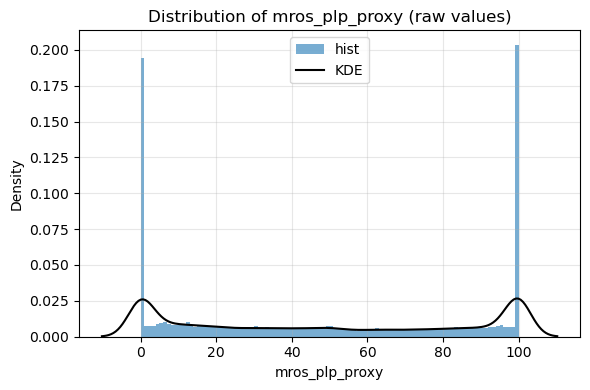

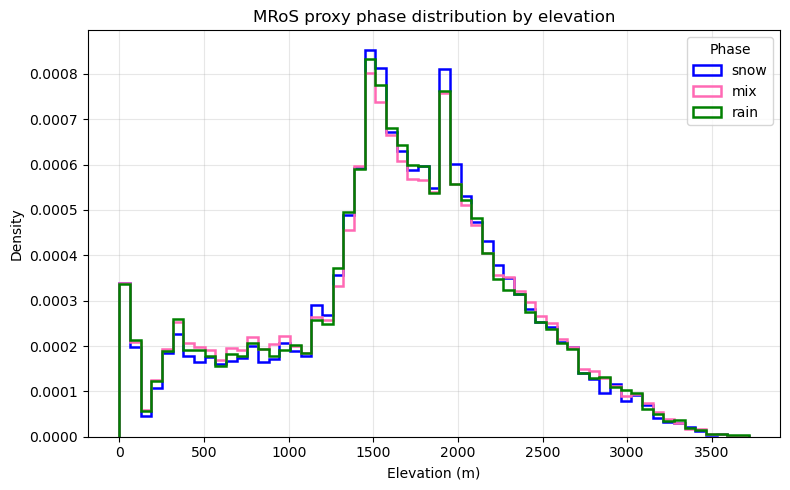

In [ ]:
# -------------------------------------------------------------------
# Visualize MRoS proxy phase distribution and predictors vs elevation
# -------------------------------------------------------------------

# Find common time range across all three datasets
common_time = np.intersect1d(
    np.intersect1d(ds_IDW["time"].values, ds_imerg["time"].values),
    ds_prism["time"].values,
)

eda_ds = xr.Dataset(
    {
        "temp_air":      ds_IDW["temp_air"].sel(time=common_time),
        "temp_dew":      ds_IDW["temp_dew"].sel(time=common_time),
        "temp_wet":      ds_IDW["temp_wet"].sel(time=common_time),
        "rh":            ds_IDW["rh"].sel(time=common_time),
        "mros_plp_proxy": ds_IDW["mros_plp_proxy"].sel(time=common_time),
        "imerg_plp":     ds_imerg["imerg_plp"].sel(time=common_time),
        "prism_tair":    ds_prism["prism_tair"].sel(time=common_time),
        "prism_tmean":   ds_prism["prism_tmean"].sel(time=common_time),
        "prism_tdmean":  ds_prism["prism_tdmean"].sel(time=common_time),
        "elev":          ds_IDW["elev"],  # broadcast over time automatically
    },
    coords={
        "time": common_time,
        "y": ds_IDW["y"],
        "x": ds_IDW["x"],
    },
)

# Stack to a 1D "sample" dimension and go to pandas for plotting
stacked = eda_ds.stack(sample=("time", "y", "x"))

# Keep only rows where the MRoS proxy exists 
df_visualize = stacked.to_dataframe().dropna(subset=["mros_plp_proxy"])

# Down-sampling for speed
max_samples = 200_000
if len(df_visualize) > max_samples:
    df_visualize = df_visualize.sample(n=max_samples, random_state=42)

# Inspect raw mros_plp_proxy
print("mros_plp_proxy summary:")
try:
    print(df_visualize["mros_plp_proxy"].describe())
except Exception as e:
    print("Could not compute describe():", e)

vals = df_visualize["mros_plp_proxy"].dropna()
arr = vals.values

# Plot histogram + optional KDE to check continuous vs discrete
plt.figure(figsize=(6, 4))
plt.hist(arr, bins=100, density=True, alpha=0.6, color="C0", label="hist")
try:
    import seaborn as sns
    sns.kdeplot(arr, bw_method='scott', color='k', label='KDE')
except Exception:
    pass
plt.xlabel("mros_plp_proxy")
plt.ylabel("Density")
plt.title("Distribution of mros_plp_proxy (raw values)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Define phase from MRoS proxy:
#    0   -> snow
#    100 -> rain
#    else -> mix
phase_arr = np.where(
    df_visualize["mros_plp_proxy"] == 0, 0,
    np.where(df_visualize["mros_plp_proxy"] == 100, 2, 1)
)

df_visualize["phase"] = phase_arr
phase_name_map = {0: "snow", 1: "mix", 2: "rain"}

# -------------------------------------------------------------------
# Phase distribution by elevation (hist overlays)
# -------------------------------------------------------------------
plt.figure(figsize=(8, 5))
bins = np.linspace(df_visualize["elev"].min(), df_visualize["elev"].max(), 60)

colors = {"snow": "blue", "mix": "#ff69b4", "rain": "green"}

for ph, name in phase_name_map.items():
    elev_vals = df_visualize.loc[df_visualize["phase"] == ph, "elev"].values
    if len(elev_vals) == 0:
        continue
    plt.hist(
        elev_vals,
        bins=bins,
        histtype="step",
        density=True,
        label=name,
        color=colors[name],
        linewidth=1.8,
    )

plt.xlabel("Elevation (m)")
plt.ylabel("Density")
plt.title("MRoS proxy phase distribution by elevation")
plt.legend(title="Phase")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


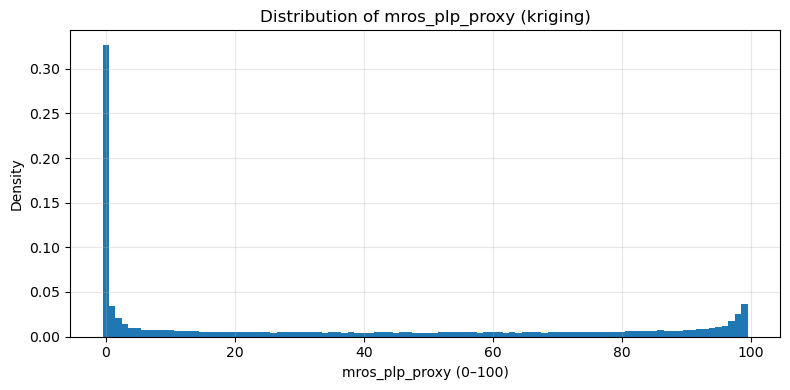

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_48736\2022035249.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["temp_bin", "proxy_cat"])


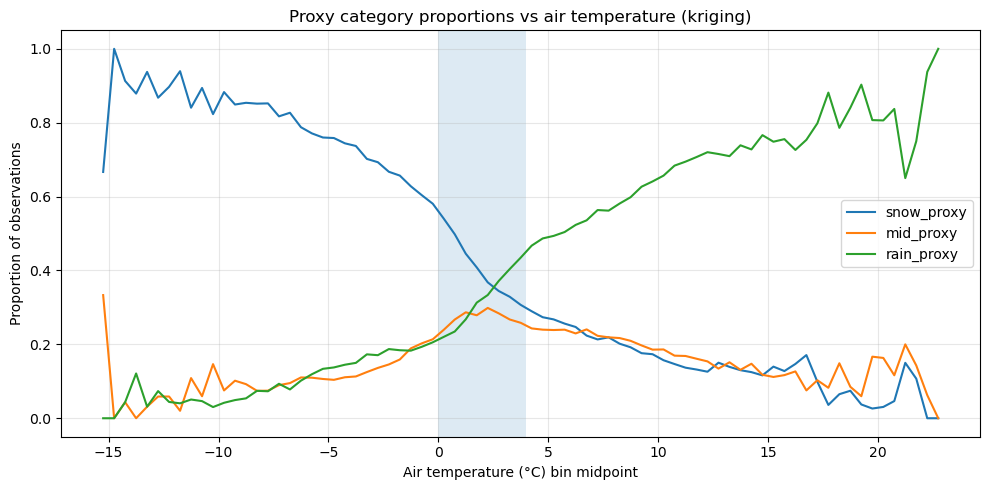

Overall mid-proxy fraction (20<proxy<80): 0.223


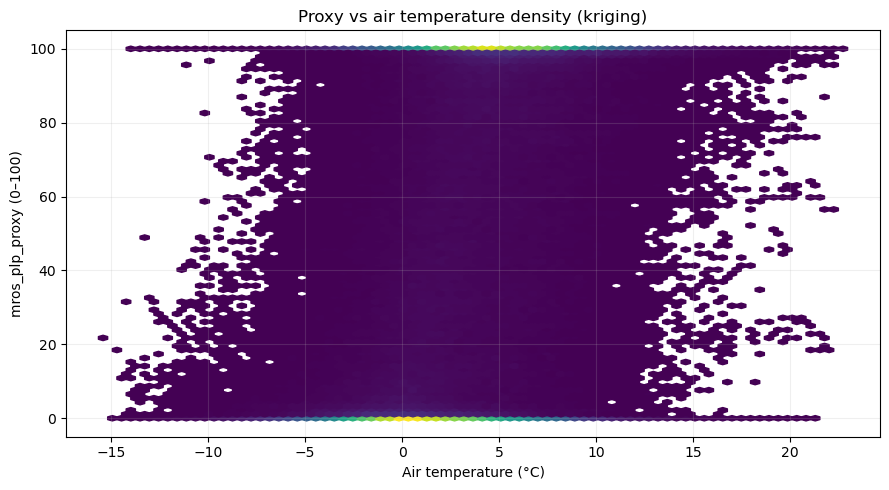

In [ ]:
# -------------------------------------------------------------------
# Diagnose MRoS proxy distribution + proxy vs air temp
# -------------------------------------------------------------------

# 1) Find common time across datasets
common_time = np.intersect1d(
    np.intersect1d(ds_interp["time"].values, ds_imerg["time"].values),
    ds_prism["time"].values,
)

# 2) Build a small dataset
eda_ds = xr.Dataset(
    {
        "temp_air": ds_interp["temp_air"].sel(time=common_time),
        "temp_wet": ds_interp["temp_wet"].sel(time=common_time),
        "mros_plp_proxy": ds_interp["mros_plp_proxy"].sel(time=common_time),
    },
    coords={"time": common_time, "y": ds_interp["y"], "x": ds_interp["x"]},
)

# 3) Stack
stacked = eda_ds.stack(sample=("time", "y", "x"))
df = stacked.to_dataframe().dropna(subset=["mros_plp_proxy", "temp_air"])

# Downsample for speed
max_samples = 300_000
if len(df) > max_samples:
    df = df.sample(n=max_samples, random_state=42)

# 4) Overall proxy distribution
plt.figure(figsize=(8,4))
plt.hist(df["mros_plp_proxy"].values, bins=np.arange(-0.5, 100.5, 1.0), density=True)
plt.xlabel("mros_plp_proxy (0–100)")
plt.ylabel("Density")
plt.title(f"Distribution of mros_plp_proxy ({interp_type})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5) Proxy category vs air temperature (proportion by temp bin)
df["proxy_cat"] = np.where(df["mros_plp_proxy"] <= 20, "snow_proxy",
                   np.where(df["mros_plp_proxy"] >= 80, "rain_proxy", "mid_proxy"))

# Temperature bins
bin_width = 0.5
tmin = np.floor(df["temp_air"].min())
tmax = np.ceil(df["temp_air"].max())
bins = np.arange(tmin, tmax + bin_width, bin_width)

df["temp_bin"] = pd.cut(df["temp_air"], bins=bins, include_lowest=True)

prop = (
    df.groupby(["temp_bin", "proxy_cat"])
      .size()
      .unstack(fill_value=0)
)
prop = prop.div(prop.sum(axis=1), axis=0)

# Make x-axis numeric
bin_mids = np.array([b.mid for b in prop.index.categories])
prop = prop.reindex(prop.index.categories)  # ensure consistent ordering

plt.figure(figsize=(10,5))
for cat in ["snow_proxy", "mid_proxy", "rain_proxy"]:
    if cat in prop.columns:
        plt.plot(bin_mids, prop[cat].values, label=cat)

plt.axvspan(0, 4, alpha=0.15)  # highlight the difficult window
plt.xlabel("Air temperature (°C) bin midpoint")
plt.ylabel("Proportion of observations")
plt.title(f"Proxy category proportions vs air temperature ({interp_type})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Quick check: what fraction are 'mid_proxy' overall?
mid_frac = (df["proxy_cat"] == "mid_proxy").mean()
print(f"Overall mid-proxy fraction (20<proxy<80): {mid_frac:.3f}")

# 6) 2D density (proxy vs temp_air)
plt.figure(figsize=(9,5))
plt.hexbin(df["temp_air"].values, df["mros_plp_proxy"].values,
           gridsize=80, mincnt=1)
plt.xlabel("Air temperature (°C)")
plt.ylabel("mros_plp_proxy (0–100)")
plt.title(f"Proxy vs air temperature density ({interp_type})")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


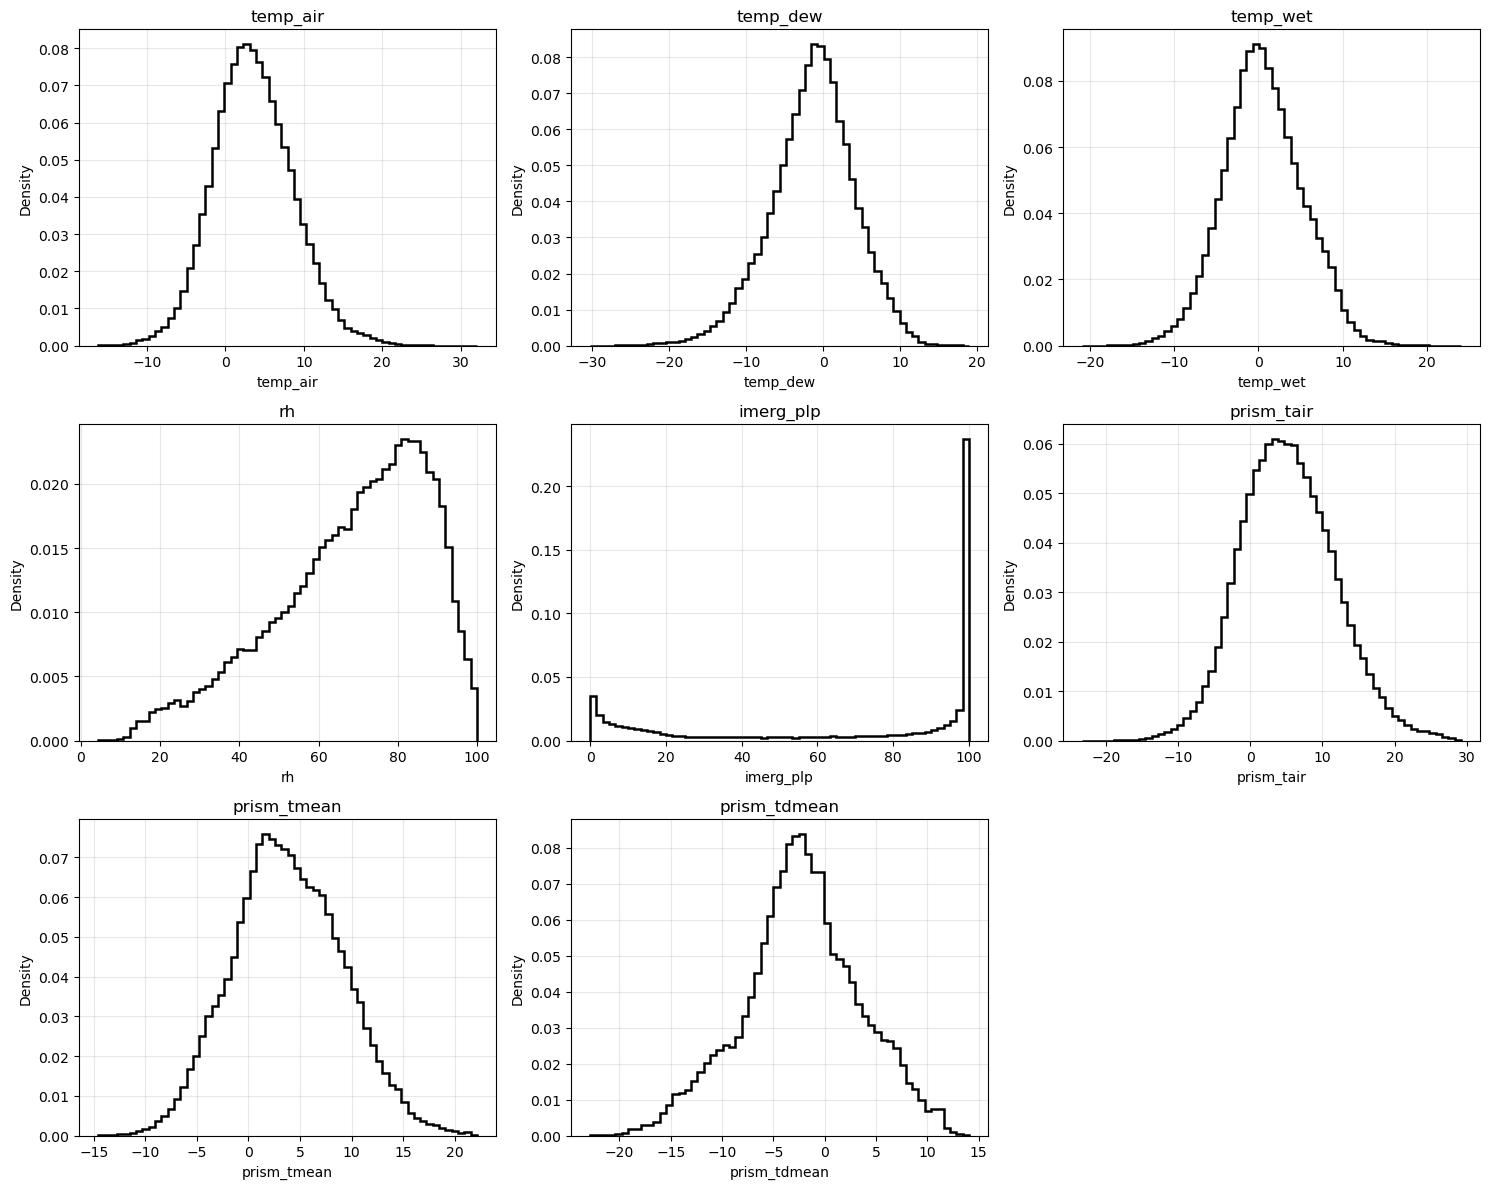

In [ ]:
# -------------------------------------------------------------------
# Predictor marginal distributions (1D density histograms)
# -------------------------------------------------------------------

predictors_plotting = [
    "temp_air",
    "temp_dew",
    "temp_wet",
    "rh",
    "imerg_plp",
    "prism_tair",
    "prism_tmean",
    "prism_tdmean",
]

n_vars = len(predictors_plotting)
n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
)
axes = axes.ravel()

for ax, var in zip(axes, predictors_plotting):
    vals = df_visualize[var].dropna().values
    if len(vals) == 0:
        ax.set_visible(False)
        continue

    ax.hist(
        vals,
        bins=60,
        density=True,
        histtype="step",
        linewidth=1.8,
        color="black",
    )

    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("Density")
    ax.grid(alpha=0.3)

for ax in axes[n_vars:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


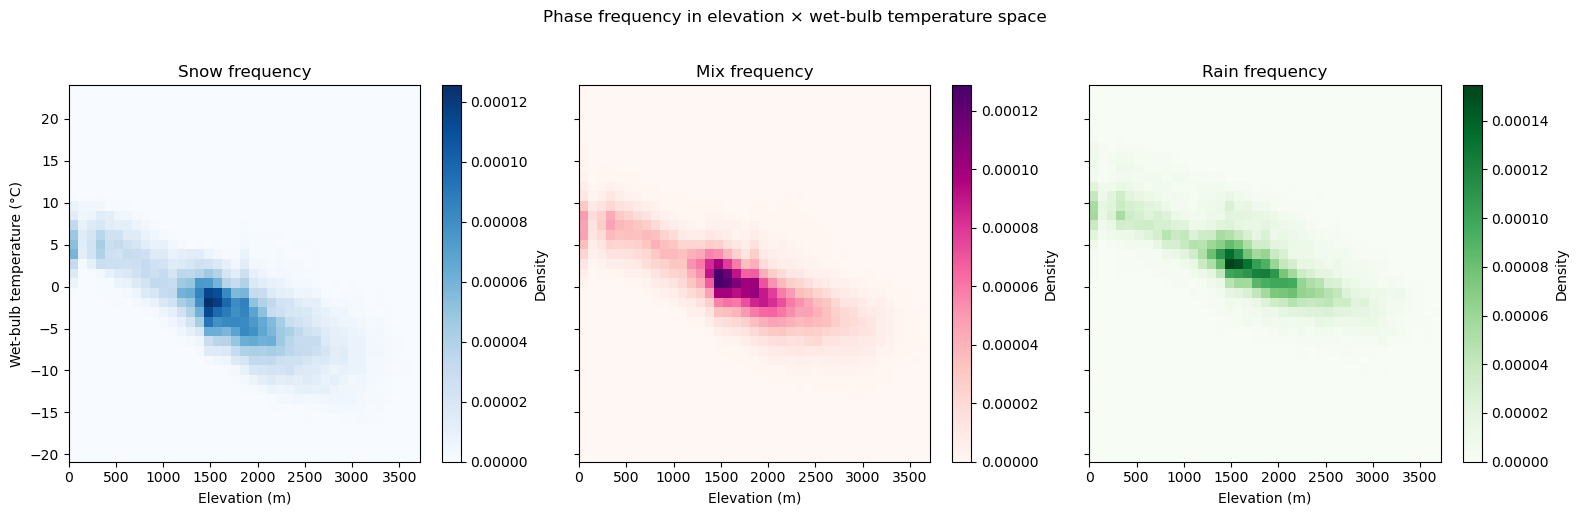

In [ ]:
# -------------------------------------------------------------------
# Elevation × wet-bulb temperature phase frequency
# -------------------------------------------------------------------

# Bin definitions
elev_bins = np.linspace(df_visualize["elev"].min(), df_visualize["elev"].max(), 40)
tw_bins   = np.linspace(df_visualize["temp_wet"].min(), df_visualize["temp_wet"].max(), 40)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

phase_labels = {0: "Snow", 1: "Mix", 2: "Rain"}
phase_colors = {0: "Blues", 1: "RdPu", 2: "Greens"}

for ax, ph in zip(axes, [0, 1, 2]):
    sub = df_visualize[df_visualize["phase"] == ph]
    h, xedges, yedges = np.histogram2d(
        sub["elev"],
        sub["temp_wet"],
        bins=[elev_bins, tw_bins],
        density=True,
    )

    im = ax.pcolormesh(
        xedges,
        yedges,
        h.T,
        cmap=phase_colors[ph],
        shading="auto",
    )

    ax.set_title(f"{phase_labels[ph]} frequency")
    ax.set_xlabel("Elevation (m)")
    if ax is axes[0]:
        ax.set_ylabel("Wet-bulb temperature (°C)")

    plt.colorbar(im, ax=ax, label="Density")

fig.suptitle("Phase frequency in elevation × wet-bulb temperature space", y=1.02)
plt.tight_layout()
plt.show()


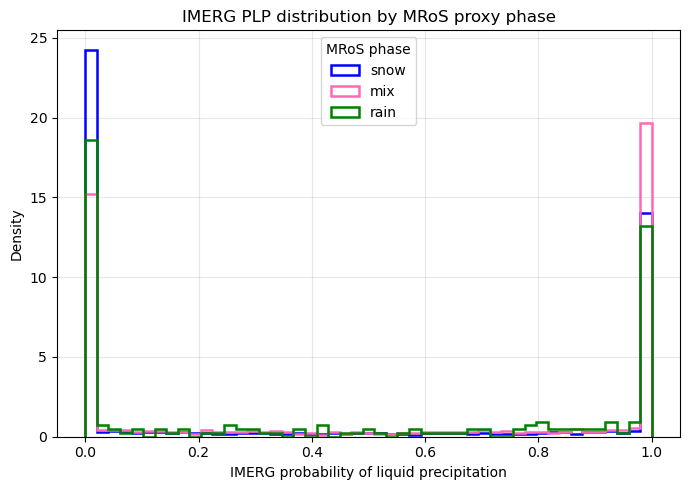

In [ ]:
# -------------------------------------------------------------------
# IMERG PLP vs MRoS phase distribution
# -------------------------------------------------------------------

plt.figure(figsize=(7, 5))

for ph, name in phase_name_map.items():
    sub = df_visualize[df_visualize["phase"] == ph]

    plt.hist(
        sub["imerg_plp"],
        bins=np.linspace(0, 1, 50),
        density=True,
        histtype="step",
        linewidth=1.8,
        label=name,
        color=colors[name],
    )

plt.xlabel("IMERG probability of liquid precipitation")
plt.ylabel("Density")
plt.title("IMERG PLP distribution by MRoS proxy phase")
plt.legend(title="MRoS phase")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


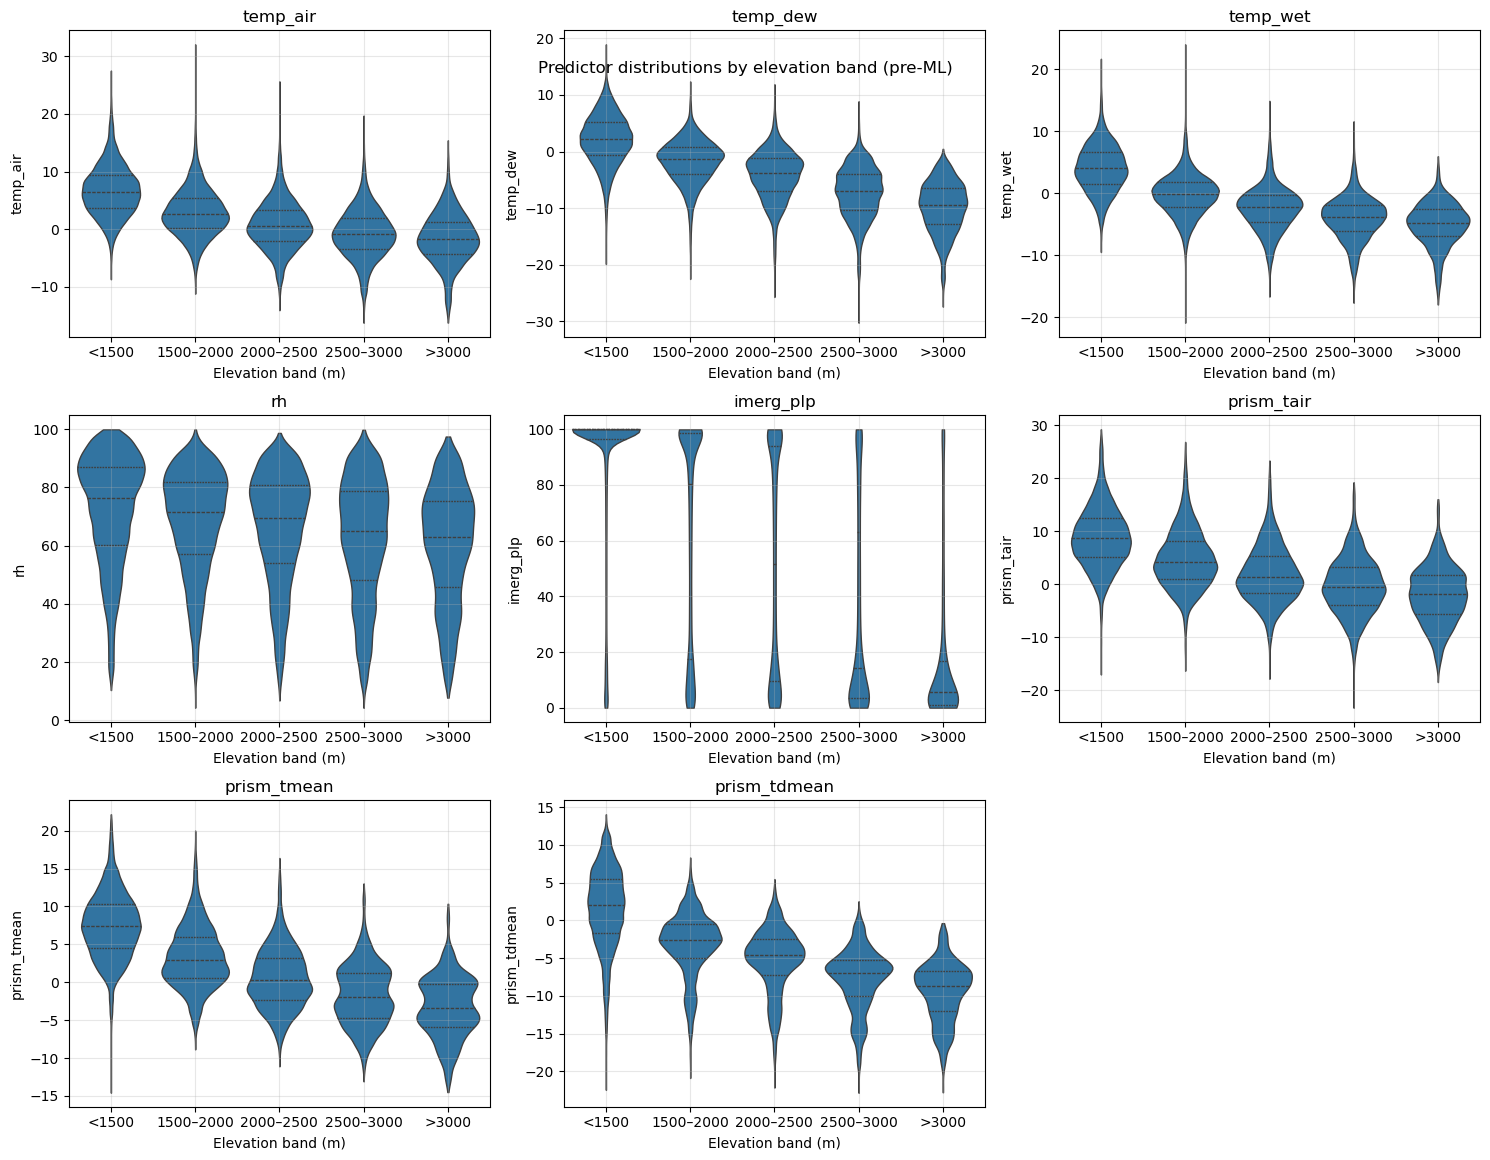

In [ ]:
# -------------------------------------------------------------------
# Violin plots: predictor distributions by elevation band (pre-ML)
# -------------------------------------------------------------------
import seaborn as sns

cols_for_viz = ["elev"] + predictors_plotting

df_visualize = df_visualize[cols_for_viz].copy()

# IMPORTANT: drop the MultiIndex completely, do NOT turn it into columns
df_visualize = df_visualize.reset_index(drop=True)

# Define elevation bands (adjust breaks if you want different bins)
elev_bins = [0, 1500, 2000, 2500, 3000, np.inf]
elev_labels = ["<1500", "1500–2000", "2000–2500", "2500–3000", ">3000"]

df_visualize["elev_band"] = pd.cut(
    df_visualize["elev"],
    bins=elev_bins,
    labels=elev_labels,
    include_lowest=True,
)

n_vars = len(predictors_plotting)
n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharex=False,
)
axes = axes.ravel()

for ax, var in zip(axes, predictors_plotting):
    sub = df_visualize[["elev_band", var]].dropna()
    if sub.empty:
        ax.set_visible(False)
        continue

    sns.violinplot(
        data=sub,
        x="elev_band",
        y=var,
        ax=ax,
        inner="quartile",
        cut=0,
        linewidth=1,
    )

    ax.set_title(var)
    ax.set_xlabel("Elevation band (m)")
    ax.set_ylabel(var)
    ax.grid(alpha=0.3)

# Hide any unused axes
for ax in axes[n_vars:]:
    ax.set_visible(False)

fig.suptitle("Predictor distributions by elevation band (pre-ML)", y=0.92)
plt.tight_layout()
plt.show()


## Step 3: Labeling & Confidence Masking

Create phase labels from the MRoS proxy and apply confidence masks to filter unreliable gridcell-hours prior to ML extraction.


In [ ]:
# -------------------------------------------------------------------
# Label thresholding: treat proxy as noisy probability surface
# snow if proxy <= 20, rain if proxy >= 80, else unlabeled for training
# -------------------------------------------------------------------

proxy = ds_interp["mros_plp_proxy"]

# Binary labels only where confident
phase = xr.where(proxy <= 20, 0,
             xr.where(proxy >= 80, 1, np.nan))

# Label confidence: distance from 50% (0 at 50, 1 at 0/100)
# This is grounded in the idea that mid-proxy values are inherently ambiguous.
label_confidence = np.abs(proxy - 50.0) / 50.0
label_confidence = label_confidence.clip(0.0, 1.0)

# Binary mask: only keep confident samples
label_mask_bin = xr.where(np.isfinite(phase), True, False)

# Create mask to enforce valid samples... 
# Not all gridcell hours are reliable from MRoS proxy (it's not actually ground truth; some estimates may be low confidence) or IMERG (many hours are non-precipitating).
label_mask = (
    ds_interp["mros_plp_proxy"].notnull() &
    (ds_imerg["imerg_plp"] > 0.05)
)

label_mask_final = label_mask & label_mask_bin

labels = xr.Dataset(
    {
        "phase": phase,
        "label_confidence": label_confidence,
        "label_mask_bin": label_mask_bin,
        "label_mask": label_mask_final,  # overwrite to enforce binary-valid samples
        "mros_plp_proxy": proxy,         # keep for diagnostics
    },
    coords=ds_interp.coords
)

# Save labels
if interp_type == "IDW":
    out_labels = SETUP_DIR / "labels_phase_hourly_1km_withIDW_v3.nc"
elif interp_type == "kriging":
    out_labels = SETUP_DIR / "labels_phase_hourly_1km_withKriging_v3.nc"
else:
    raise ValueError(f"Unknown interp_type: {interp_type}")

labels.to_netcdf(
    out_labels,
    encoding={
        "phase": {"zlib": True},
        "label_confidence": {"zlib": True},
        "label_mask": {"zlib": True},
        "mros_plp_proxy": {"zlib": True},
    }
)
print("Saved labels to:", out_labels)


Saved labels to: C:\Users\EmmaGolub\Desktop\MRoS_local\local_data\compiled_input_predictors\labels_phase_hourly_1km_withKriging_v3.nc


## Step 3.5: Gridded to tabular extraction + spatial blocking

In [27]:
# Parquets will be much faster to use in ML... convert aligned gridded predictors + labels into a single, analysis-ready tabular dataset, apply label masking, assign spatial blocks, and write to Parquet once.

# SETUP_DIR = DATA_DIR / "compiled_input_predictors"
# predictors = xr.open_dataset(SETUP_DIR / "predictors_hourly_1km.nc")
# labels     = xr.open_dataset(SETUP_DIR / "labels_phase_hourly_1km.nc")

# Check label mask
label_mask = labels["label_mask"]

mask_frac = float(label_mask.mean())
print(f"Fraction of gridcell-hours kept: {mask_frac:.3f}")

Fraction of gridcell-hours kept: 0.101


In [44]:
# Reshaping/stacking to convert each (time, x, y) gridcell into one ML sample

predictors_stacked = predictors.stack(sample=("time", "y", "x"))
labels_stacked     = labels.stack(sample=("time", "y", "x"))
mask_stacked       = label_mask.stack(sample=("time", "y", "x"))

# Apply confidence mask after stacking to remove entire samples that fail label validity criteria.
# This helps ensure that every retained sample has a usable phase label.
# Also reduces dataset size to enhance label quality.
predictors_valid = predictors_stacked.where(mask_stacked, drop=True)
labels_valid     = labels_stacked.where(mask_stacked, drop=True)


# At this point:
# - every remaining row has a valid phase label
# - no NaN label rows survive

# Up until this point, xarray was useful because it enforced coordinate alignment and supported labeled dimensions.
# ML libraries require 2D tabular inputs, so convert to pandas:

# Convert to pandas
X = predictors_valid.to_dataframe()
y = labels_valid[["phase", "label_confidence"]].to_dataframe()[["phase", "label_confidence"]]  # phase target + confidence

# Identify index names (these will be inserted by reset_index) and enforce uniqueness prior to flattening
index_cols = X.index.names  # typically ['time', 'y', 'x']

# Master dataframe of reshaped gridcell-time samples with mask applied; contains predictor columns
master_df = (
    X.drop(columns=index_cols, errors="ignore")
     .join(y, how="inner")
     .reset_index()
)

# Feature engineering: add anomalies (signal + discrepancy)
master_df["T_anom"]  = master_df["temp_air"] - master_df["prism_tair"]
master_df["Td_anom"] = master_df["temp_dew"] - master_df["prism_tdmean"]


print(master_df.columns)

assert master_df.columns.duplicated().sum() == 0

# Now each row is a single gridcell at a single hour.
# Predictor columns
# Target phase column
# Spatiotemporal metadata columns (x, y, time)

Index(['time', 'y', 'x', 'temp_air', 'temp_dew', 'temp_wet', 'rh', 'imerg_plp',
       'prism_tair', 'prism_tmean', 'prism_tdmean', 'elev', 'phase',
       'label_confidence', 'T_anom', 'Td_anom'],
      dtype='object')


In [45]:
# Check class balance (by phase)
master_df["phase"].value_counts(normalize=True)

phase
1.0    0.512739
0.0    0.487261
Name: proportion, dtype: float64

## Step 4: Spatial Blocking
### 4a: Defining spatial blocks
Motivation: Standard random cross-validation grossly overestimates ML skill when data are spatially autocorrelated.
Guiding literature: Stock & Subramaniam (2022); https://doi.org/10.1080/15481603.2022.2107113
- Random splits allow near-duplicate information to leak across train/test
- Reported accuracy becomes meaningless for true spatial generalization

In our case, neighboring gridcells share:
- elevation
- meteorology
- storm structure
Random CV would dramatically overestimate phase-prediction skill

In [48]:
# Each row = one labeled gridcell-hour
# predictors:
    # temp_air, temp_dew, temp_wet, rh,
    # imerg_plp,
    # prism_tair, prism_tmean, prism_tdmean, prism_ppt_daily,
    # elev
# target: phase (0 snow / 1 mix / 2 rain)
# metadata: time, x, y, block_id

BLOCK_SIZE_M = 25_000

master_df["block_x"] = (master_df["x"] // BLOCK_SIZE_M).astype(np.int32)
master_df["block_y"] = (master_df["y"] // BLOCK_SIZE_M).astype(np.int32)

master_df["block_id"] = list(zip(master_df["block_x"], master_df["block_y"]))

print(master_df["block_id"].nunique(), "unique spatial blocks")

master_df["block_id"].value_counts().describe()



77 unique spatial blocks


count        77.000000
mean     241025.831169
std      124029.763957
min        2048.000000
25%      161347.000000
50%      306556.000000
75%      335126.000000
max      378434.000000
Name: count, dtype: float64

In [49]:
# Drop tiny blocks
block_counts = master_df["block_id"].value_counts()

keep_blocks = block_counts[block_counts >= 25_000].index
master_df = master_df[master_df["block_id"].isin(keep_blocks)].copy()

print("Blocks kept:", master_df["block_id"].nunique())
master_df["block_id"].value_counts().describe()


Blocks kept: 70


count        70.000000
mean     264063.114286
std      104975.066572
min       46702.000000
25%      169527.750000
50%      311961.000000
75%      335954.500000
max      378434.000000
Name: count, dtype: float64

### 4b: Random Block Splitting

Starting with single-partition spatial holdout validation (random block split). 
Can try full iterative spatial leave-one-out-cross-validation (SLOO-CV) later.

In [50]:
# Extract unique blocks and shuffle
# 
rng = np.random.default_rng(42)

blocks = master_df["block_id"].unique()
rng.shuffle(blocks)

n_blocks = len(blocks)
print("Total blocks:", n_blocks)


Total blocks: 70


In [51]:
# Define split sizes (70 / 15/ 15)
n_train = int(0.70 * n_blocks)
n_val   = int(0.15 * n_blocks)

train_blocks = set(blocks[:n_train])
val_blocks   = set(blocks[n_train:n_train + n_val])
test_blocks  = set(blocks[n_train + n_val:])

assert train_blocks.isdisjoint(val_blocks)
assert train_blocks.isdisjoint(test_blocks)
assert val_blocks.isdisjoint(test_blocks)

print(len(train_blocks), len(val_blocks), len(test_blocks))

49 10 11


In [52]:
# Assign split labels to rows

def assign_split(bid):
    if bid in train_blocks:
        return "train"
    elif bid in val_blocks:
        return "val"
    else:
        return "test"

# This master_df master table is now the bridge between ML space and geophysical space.
master_df["split"] = master_df["block_id"].map(assign_split)

assert master_df["split"].notna().all()
print(master_df["split"].value_counts(normalize=True))

split
train    0.693012
test     0.160654
val      0.146334
Name: proportion, dtype: float64


In [53]:
# Class balance diagnostics
phase_map = {0: "snow", 1: "rain"}

overall = (
    master_df["phase"]
    .value_counts(normalize=True)
    .rename(index=phase_map)
)

print("Overall class balance:")
print(overall)


Overall class balance:
phase
rain    0.51252
snow    0.48748
Name: proportion, dtype: float64


In [54]:
by_split = (
    master_df.groupby("split")["phase"]
      .value_counts(normalize=True)
      .rename(index=phase_map)
      .unstack()
)

print("Class balance by split:")
print(by_split)

Class balance by split:
phase      rain      snow
split                    
test   0.523943  0.476057
train  0.506783  0.493217
val    0.527149  0.472851


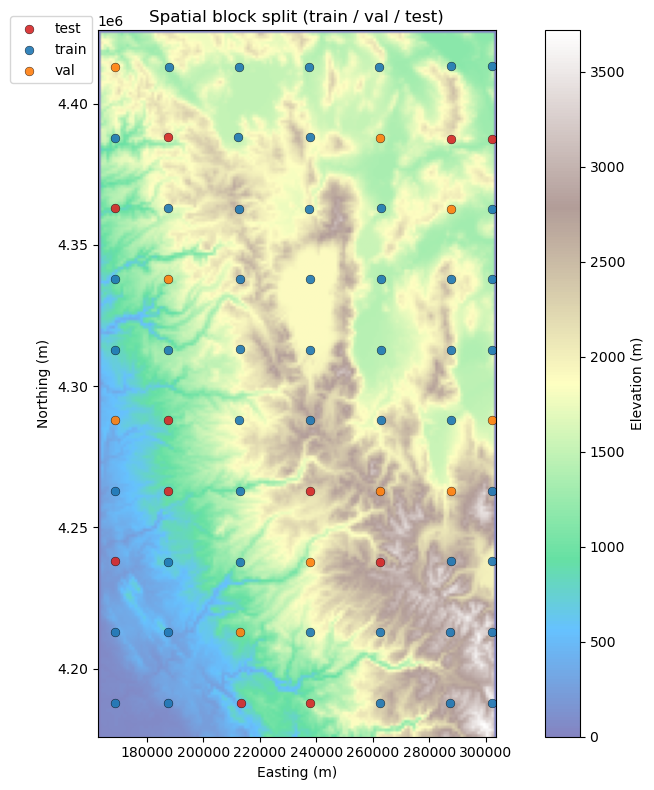

split
test      2969590
train    12809927
val       2704901
Name: n_samples, dtype: int64

In [40]:
# Spatial diagnostics (plot spatial block split over DEM)

# Select DEM
dem = ds_interp["elev"]  # our DEM exists in any of the interpolated datasets

# Handle nodata if present
dem_vals = dem.values
if "_FillValue" in dem.attrs:
    dem_vals = np.where(dem_vals == dem.attrs["_FillValue"], np.nan, dem_vals)

# Compute spatial extent from coords
extent = [
    float(dem["x"].min()),
    float(dem["x"].max()),
    float(dem["y"].min()),
    float(dem["y"].max())
]

# Decide origin based on y direction
if float(dem["y"][0]) > float(dem["y"][-1]):
    # y decreases from north to south → put row 0 at the top (max y)
    origin = "upper"
else:
    origin = "lower"

# Spatial diagnostics
block_df = (
    master_df.groupby("block_id")
      .agg(
          x_mean=("x", "mean"),
          y_mean=("y", "mean"),
          split=("split", "first"),
          n=("phase", "size")
      )
      .reset_index()
)

colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:red"}

fig, ax = plt.subplots(figsize=(10, 8))

# 1) DEM underlay
im = ax.imshow(
    dem_vals,
    extent=extent,
    origin=origin,
    cmap="terrain",
    alpha=0.6
)

# 2) Block centroids
for split, g in block_df.groupby("split"):
    ax.scatter(
        g["x_mean"], g["y_mean"],
        s=40,
        c=colors[split],
        label=split,
        alpha=0.9,
        edgecolor="k",
        linewidths=0.3
    )

ax.legend(
    loc="upper left",
    bbox_to_anchor=(-0.22, 1.02),  # left of axes, slightly above
    frameon=True,
    borderaxespad=0.0
)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Spatial block split (train / val / test)")
ax.set_aspect("equal")

cbar = fig.colorbar(im, ax=ax, label="Elevation (m)")
fig.tight_layout()
fig.savefig(GRAPHICS_DIR / f"spatial_block_split_{interp_type}.png", dpi=200, bbox_inches="tight")
plt.show()

master_df.groupby("split").size().rename("n_samples")


## Step 5: XGBoost Model Architecture

In [55]:
FEATURES = [
    # station-interpolated thermo
    "temp_air", "temp_dew", "temp_wet", "rh",

    # precip products
    "imerg_plp",

    # topography
    "elev",

    # discrepancy features
    "T_anom",
    "Td_anom",
]

TARGET = "phase"  # 0=snow, 1=rain

# Prepare matrices
X_train = master_df.loc[master_df["split"] == "train", FEATURES]
y_train = master_df.loc[master_df["split"] == "train", TARGET].astype(int)

X_val   = master_df.loc[master_df["split"] == "val", FEATURES]
y_val   = master_df.loc[master_df["split"] == "val", TARGET].astype(int)

X_test  = master_df.loc[master_df["split"] == "test", FEATURES]
y_test  = master_df.loc[master_df["split"] == "test", TARGET].astype(int)

# Pull label confidence too
c_train = master_df.loc[master_df["split"] == "train", "label_confidence"].values
c_val   = master_df.loc[master_df["split"] == "val",   "label_confidence"].values
c_test  = master_df.loc[master_df["split"] == "test",  "label_confidence"].values


In [ ]:
# Handle class imbalance... compute class weights from training set
from sklearn.utils.class_weight import compute_class_weight

# Binary classes
classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train.values
)
class_weight = dict(zip(classes, weights))
print("Class weights:", class_weight)

# Base weights from class imbalance
w_train = y_train.map(class_weight).values
w_val   = y_val.map(class_weight).values

# Multiply by label confidence
w_train = w_train * c_train
w_val   = w_val * c_val

# Transition-window upweight: emphasize 0–4°C wet-bulb
alpha = 1.0  # start with 1.0; tune later (0.5–2.0 is a reasonable range)
tw_train = master_df.loc[master_df["split"] == "train", "temp_wet"].values
tw_val   = master_df.loc[master_df["split"] == "val",   "temp_wet"].values

transition_train = ((tw_train >= 0.0) & (tw_train <= 4.0)).astype(float)
transition_val   = ((tw_val   >= 0.0) & (tw_val   <= 4.0)).astype(float)

w_train = w_train * (1.0 + alpha * transition_train)
w_val   = w_val   * (1.0 + alpha * transition_val)

sample_weight_train = w_train
sample_weight_val   = w_val

Class weights: {np.int64(0): np.float64(1.013753331912013), np.int64(1): np.float64(0.9866148489384703)}


### Train!

[0]	train-logloss:0.67471	val-logloss:0.67442
[50]	train-logloss:0.46455	val-logloss:0.49017
[100]	train-logloss:0.43709	val-logloss:0.46825
[150]	train-logloss:0.42499	val-logloss:0.45839
[200]	train-logloss:0.41589	val-logloss:0.45123
[250]	train-logloss:0.40784	val-logloss:0.44510
[300]	train-logloss:0.40082	val-logloss:0.43941
[350]	train-logloss:0.39419	val-logloss:0.43402
[400]	train-logloss:0.38780	val-logloss:0.42931
[450]	train-logloss:0.38212	val-logloss:0.42490
[500]	train-logloss:0.37769	val-logloss:0.42153
[550]	train-logloss:0.37333	val-logloss:0.41813
[600]	train-logloss:0.36929	val-logloss:0.41514
[650]	train-logloss:0.36549	val-logloss:0.41240
[700]	train-logloss:0.36203	val-logloss:0.40997
[750]	train-logloss:0.35877	val-logloss:0.40759
[800]	train-logloss:0.35528	val-logloss:0.40474
[850]	train-logloss:0.35229	val-logloss:0.40247
[900]	train-logloss:0.34924	val-logloss:0.40007
[950]	train-logloss:0.34605	val-logloss:0.39765
[1000]	train-logloss:0.34344	val-logloss:0.

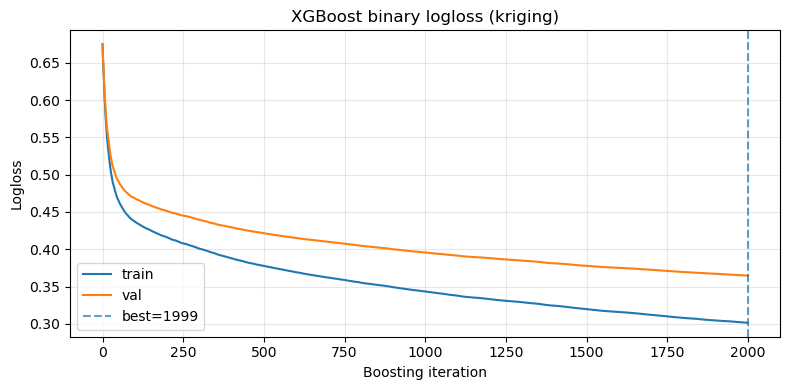

Abstention rate (mix/uncertain): 0.111
Accuracy on non-abstained samples: 0.880 (n=2641032)

Confusion matrix (non-abstained only; rows=true [snow,rain], cols=pred [snow,rain]):
[[1107278  140718]
 [ 175496 1217540]]

Classification report (non-abstained only):
              precision    recall  f1-score   support

        snow       0.86      0.89      0.88   1247996
        rain       0.90      0.87      0.89   1393036

    accuracy                           0.88   2641032
   macro avg       0.88      0.88      0.88   2641032
weighted avg       0.88      0.88      0.88   2641032



In [57]:
import xgboost as xgb

params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": 6,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "lambda": 1.0,
    "tree_method": "hist",
    "seed": 42,
}

dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weight_train)
dval   = xgb.DMatrix(X_val,   label=y_val,   weight=sample_weight_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)

evals = [(dtrain, "train"), (dval, "val")]
evals_result = {}

booster = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=evals,
    evals_result=evals_result,
    early_stopping_rounds=50,
    verbose_eval=50,
)

# Loss curves
train_loss = evals_result["train"]["logloss"]
val_loss   = evals_result["val"]["logloss"]

plt.figure(figsize=(8,4))
plt.plot(train_loss, label="train")
plt.plot(val_loss, label="val")
plt.axvline(booster.best_iteration, ls="--", alpha=0.7, label=f"best={booster.best_iteration}")
plt.xlabel("Boosting iteration")
plt.ylabel("Logloss")
plt.title(f"XGBoost binary logloss ({interp_type})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Predict probabilities on test
p_rain = booster.predict(dtest)          # P(class=1)
p_snow = 1.0 - p_rain
max_prob = np.maximum(p_rain, p_snow)

# Abstention rule -> "mix/uncertain" if max(prob) < 0.6
abstain_thresh = 0.6
y_pred_abst = np.where(
    max_prob < abstain_thresh,
    2,  # 2 = mix/uncertain
    (p_rain >= 0.5).astype(int)  # 0 snow, 1 rain
)

# Report abstention rate + accuracy on non-abstained
abstain_rate = np.mean(y_pred_abst == 2)
mask_keep = (y_pred_abst != 2)
acc_keep = np.mean((y_pred_abst[mask_keep] == y_test.values[mask_keep])) if mask_keep.any() else np.nan

print(f"Abstention rate (mix/uncertain): {abstain_rate:.3f}")
print(f"Accuracy on non-abstained samples: {acc_keep:.3f} (n={mask_keep.sum()})")

# Optional: confusion on non-abstained only
from sklearn.metrics import confusion_matrix, classification_report

print("\nConfusion matrix (non-abstained only; rows=true [snow,rain], cols=pred [snow,rain]):")
print(confusion_matrix(y_test.values[mask_keep], y_pred_abst[mask_keep], labels=[0,1]))

print("\nClassification report (non-abstained only):")
print(classification_report(y_test.values[mask_keep], y_pred_abst[mask_keep], labels=[0,1], target_names=["snow","rain"]))
